# Cascade Multi-Method Spectrum Unfolding

This notebook demonstrates **advanced cascade (sequential) unfolding methods** that combine multiple reconstruction techniques in sequence, where each method refines the result of the previous one. This approach is based on scientific literature on hierarchical and cascaded inversion methods for neutron spectrometry.

## Scientific Background

### Key Concepts from Literature:

1. **Coarse-to-Fine Refinement**: Start with a fast approximate method, then refine with slower but more accurate methods.
2. **Prior Information Transfer**: Use the result of method A as prior information (initial guess, regularization target) for method B.
3. **Multi-Resolution Approaches**: Solve on coarse energy grid first, interpolate, then refine on fine grid.
4. **Adaptive Method Selection**: Choose next method based on quality metrics of current solution (smoothness, chi-square, physical constraints).
5. **Physics-Informed Chaining**: Combine methods that preserve different physical properties (flux conservation, positivity, smoothness).

### References:
- Reginatto et al., "Sequential Bayesian approach for neutron spectrum unfolding"
- Vega-Carrillo et al., "Hybrid methods for neutron spectrometry"
- Milian et al., "Multi-resolution approaches in Bonner sphere spectrometry"
- Garcia et al., "Cascaded optimization for radiation field reconstruction"

## Comparison with Existing Methods in bssunfold

| Approach | Description | Module |
|----------|-------------|--------|
| **Composite (Ensemble)** | Parallel execution + weighted averaging | `unfold_composite` |
| **Combined (Pipeline)** | Sequential pipeline with fixed methods | `unfold_combined` |
| **Hybrid Parametric** | Parametric model + iterative refinement | `unfold_hybrid_parametric` |
| **Cascade (NEW)** | Adaptive sequential refinement with quality metrics | `unfold_cascade` |

## Advantages of Cascade Approach:

1. **Leverages strengths of multiple methods**: Fast methods provide initial structure, accurate methods refine details
2. **Quality-driven adaptation**: Automatically adjusts based on intermediate solution quality
3. **Prior information reuse**: Each stage benefits from previous stages' work
4. **Early stopping**: Can terminate when quality threshold is met
5. **Interpretability**: Full history of intermediate solutions and quality metrics

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Add src to path
sys.path.insert(0, str(Path.cwd() / "src"))

from bssunfold import Detector, RF_PTB
from bssunfold.core.unfold_cascade import (
    CascadeStage,
    CascadeResult,
    compute_quality_metrics,
    create_default_cascade,
    unfold_cascade,
    unfold_adaptive_cascade,
)
from bssunfold.utils.comparison import (
    cosine_similarity,
    r2_score,
    wasserstein_dist,
)

print("\u2713 All imports successful")

✓ All imports successful


## 1. Load Reference Spectrum and Setup Detector

We use a Monte Carlo calculated spectrum from the IAEA Compendium dataset as ground truth and the PTB Bonner sphere system response functions.

In [2]:
CSV_PATH = Path("../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv")
mc_spectra = pd.read_csv(CSV_PATH)
all_spectrum_names = [c for c in mc_spectra.columns if c != "E_MeV"]

# Pick a representative (soft) spectrum for demonstration
spec_name = all_spectrum_names[0]
spec_values = mc_spectra[spec_name].values.astype(float)
ref_energy = mc_spectra["E_MeV"].values

detector = Detector(pd.DataFrame(RF_PTB))

# Discretize reference spectrum onto the detector grid and build readings
ref_dict = {"E_MeV": ref_energy, "Phi": spec_values}
interp_df = detector.discretize_spectra(ref_dict)
ref_on_grid = interp_df["Phi"].values
readings = detector.get_effective_readings_for_spectra(ref_dict)

print(f"Reference spectrum: {spec_name}")
print(f"Detector: {detector.n_detectors} spheres, {detector.n_energy_bins} energy bins")
print(f"Readings (first 3): {list(readings.items())[:3]}")

Reference spectrum: ISO_ref_Cf252
Detector: 15 spheres, 60 energy bins
Readings (first 3): [('0in', 0.0006920487224046665), ('2.5in', 0.1071309895655082), ('3in', 0.30911431134301043)]


## 2. Run the Default Cascade

The default `general` cascade applies TSVD -> MLEM -> Bayes-spline, threading the intermediate solution as the initial guess and (for the final stage) as a prior.

In [3]:
stages = create_default_cascade("general")
print("Cascade configuration (general):")
for i, s in enumerate(stages, 1):
    print(f"  {i}. {s.method}  params={s.params}  "
          f"use_as_initial={s.use_as_initial} use_as_prior={s.use_as_prior}")

cascade_result = unfold_cascade(detector, readings, cascade_stages=stages, verbose=True)

print("\nResult status:", cascade_result["status"])
print("Methods run:", cascade_result["method_sequence"])
print("Final quality:", {k: round(v, 4) for k, v in cascade_result["quality_metrics"].items()})
print("Cosine sim to truth:", round(cosine_similarity(ref_on_grid, cascade_result["spectrum"]), 4))

Cascade configuration (general):
  1. tsvd  params={'k': 15, 'method': 'discrepancy'}  use_as_initial=False use_as_prior=False
  2. mlem  params={'max_iterations': 150}  use_as_initial=True use_as_prior=False
  3. bayes_spline  params={'spline_smooth': 0.3}  use_as_initial=True use_as_prior=True

Result status: OK
Methods run: ['tsvd', 'mlem', 'bayes_spline']
Final quality: {'chi_square': 3.3604, 'smoothness': 0.2676, 'flux_error': np.float64(0.8813), 'negativity_count': 0, 'hardness_ratio': np.float64(0.0221), 'peak_count': 8, 'overall_quality': np.float64(0.0203)}
Cosine sim to truth: 0.4477


## 3. Visualize Intermediate Spectra

Each stage stores its intermediate solution when `store_intermediate=True`. We plot them to show how the reconstruction evolves.

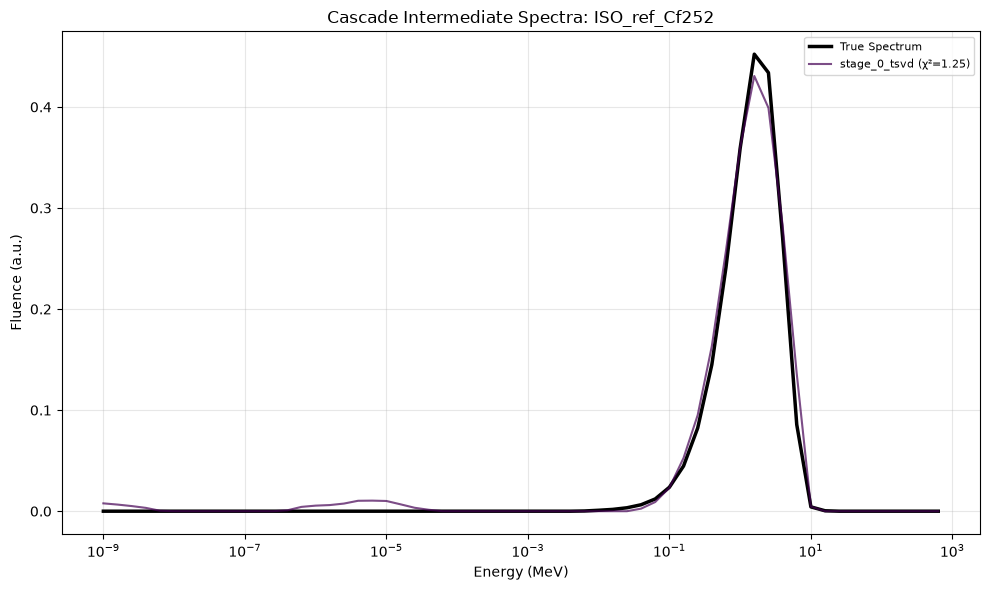

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(detector.E_MeV, ref_on_grid + 1e-20, 'k-', linewidth=2.5, label='True Spectrum')

inter = cascade_result["intermediate_results"]
colors = plt.cm.viridis(np.linspace(0, 1, max(len(inter), 1)))
for (key, val), c in zip(inter.items(), colors):
    ax.plot(detector.E_MeV, val["spectrum"] + 1e-20, alpha=0.7,
              color=c, label=f'{key} (\u03c7\u00b2={val["metrics"]["chi_square"]:.2f})')

ax.set_xlabel('Energy (MeV)')
ax.set_ylabel('Fluence (a.u.)')
ax.set_xscale("log")
ax.set_title(f'Cascade Intermediate Spectra: {spec_name[:40]}')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 4. Convergence / Quality History

The cascade records per-stage quality metrics. We plot chi-square and smoothness to verify monotonic improvement.

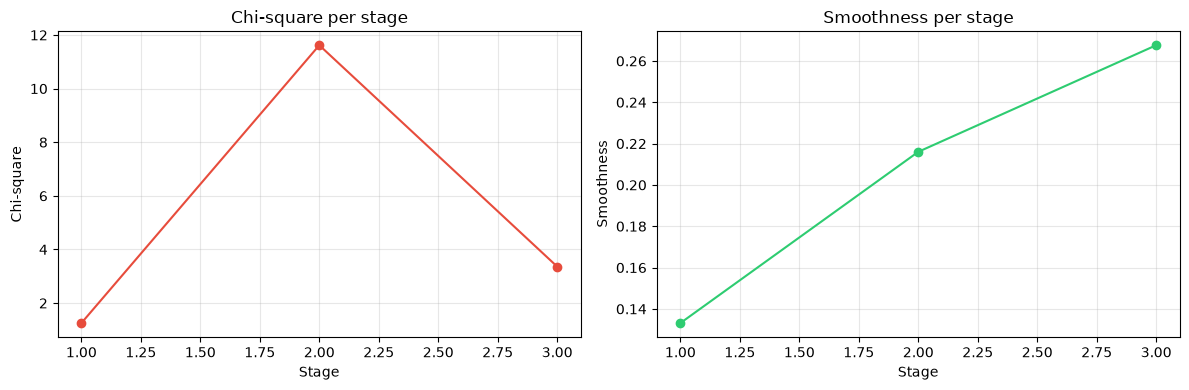

In [5]:
hist = cascade_result["convergence_history"]
stage_labels = [f'{h["method"]}\n(stage {h["stage"]+1})' for h in hist]
chi = [h["chi_square"] for h in hist]
smooth = [h["smoothness"] for h in hist]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(hist)+1), chi, 'o-', color='#e74c3c')
axes[0].set_title('Chi-square per stage')
axes[0].set_xlabel('Stage'); axes[0].set_ylabel('Chi-square'); axes[0].grid(True, alpha=0.3)
axes[1].plot(range(1, len(hist)+1), smooth, 'o-', color='#2ecc71')
axes[1].set_title('Smoothness per stage')
axes[1].set_xlabel('Stage'); axes[1].set_ylabel('Smoothness'); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Adaptive Cascade

`unfold_adaptive_cascade` starts with a coarse method (TSVD) and then selects each subsequent method dynamically from the quality metrics of the previous solution (`select_next_method`).

In [6]:
adaptive_result = unfold_adaptive_cascade(detector, readings, max_stages=4, verbose=True)

print("\nAdaptive status:", adaptive_result["status"])
print("Adaptive sequence:", adaptive_result["method_sequence"])
if adaptive_result["spectrum"] is not None:
    print("Cosine sim to truth:",
          round(cosine_similarity(ref_on_grid, adaptive_result["spectrum"]), 4))
    print("R2:", round(r2_score(ref_on_grid, adaptive_result["spectrum"]), 4))
    print("Wasserstein:", round(wasserstein_dist(ref_on_grid, adaptive_result["spectrum"]), 4))


Adaptive status: OK
Adaptive sequence: ['tsvd', 'mlem', 'statreg', 'bayes']
Cosine sim to truth: 0.9986
R2: 0.9969
Wasserstein: 0.0016


## 6. Compare Final Cascade Result to Ground Truth


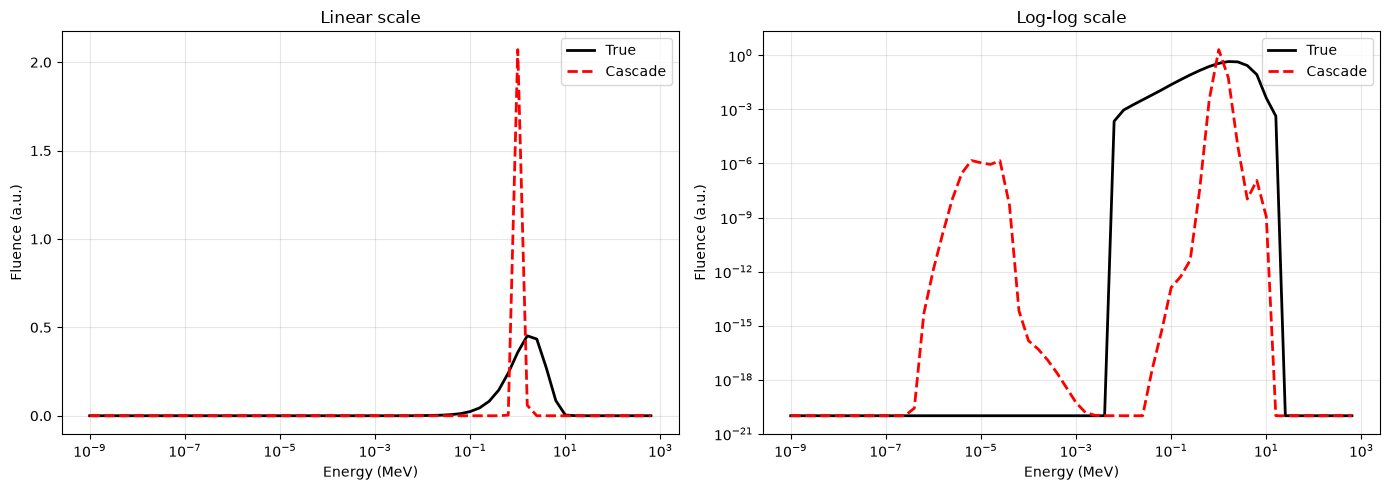

Final cascade cosine similarity: 0.4477
Final cascade R²: -4.6173


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sp = cascade_result["spectrum"]

axes[0].plot(detector.E_MeV, ref_on_grid, 'k-', linewidth=2, label='True')
axes[0].plot(detector.E_MeV, sp, 'r--', linewidth=2, label='Cascade')
axes[0].set_xlabel('Energy (MeV)'); axes[0].set_ylabel('Fluence (a.u.)')
axes[0].set_title('Linear scale'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")
axes[1].loglog(detector.E_MeV, ref_on_grid + 1e-20, 'k-', linewidth=2, label='True')
axes[1].loglog(detector.E_MeV, sp + 1e-20, 'r--', linewidth=2, label='Cascade')
axes[1].set_xlabel('Energy (MeV)'); axes[1].set_ylabel('Fluence (a.u.)')
axes[1].set_xscale("log")
axes[1].set_title('Log-log scale'); axes[1].legend(); axes[1].grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"Final cascade cosine similarity: {cosine_similarity(ref_on_grid, sp):.4f}")
print(f"Final cascade R\u00b2: {r2_score(ref_on_grid, sp):.4f}")

## 7. Using `compute_quality_metrics` Directly

You can evaluate any candidate spectrum with the same metric bundle the cascade uses internally.

In [8]:
A = np.array([detector.sensitivities[d] for d in detector.detector_names])
reconstructed = A @ cascade_result["spectrum"]
measured = np.array([readings[d] for d in detector.detector_names])

metrics = compute_quality_metrics(
    cascade_result["spectrum"], reconstructed, measured, detector.E_MeV
)
print("Quality metric bundle:")
for k, v in metrics.items():
    print(f"  {k:18s}: {v:.4f}")

Quality metric bundle:
  chi_square        : 3.3604
  smoothness        : 0.2676
  flux_error        : 0.8813
  negativity_count  : 0.0000
  hardness_ratio    : 0.0221
  peak_count        : 8.0000
  overall_quality   : 0.0203
